

Searching for matching track for Jul2021 at 2021-07-12 00:00:00
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor250_mar-oct2021_DET/ff_trs_pos.addwind250_addwind10m_addmslp_addprecip.new.nc
<xarray.Dataset> Size: 3MB
Dimensions:                    (tracks: 1410, record: 30416)
Coordinates:
    TRACK_ID                   (tracks) int32 6kB ...
    time                       (record) datetime64[ns] 243kB ...
    longitude                  (record) float32 122kB ...
    latitude                   (record) float32 122kB ...
    longitude_1                (record) float32 122kB ...
    latitude_1                 (record) float32 122kB ...
    longitude_2                (record) float32 122kB ...
    latitude_2                 (record) float32 122kB ...
    longitude_3                (record) float32 122kB ...
    latitude_3                 (record) float32 122kB ...
Dimensions without coordinates: tracks, record
Data variables:
    FIRST_PT                   (tracks) in

,Track ID,Start Time,End Time,Min MSLP (hPa),Max WSP10m (m/s),Max Int Lon,Max Int Lat,Max Int Time
0,715,2021-06-27 00:00:00,2021-07-12 18:00:00,999.210022,16.373249,279.764496,43.441082,2021-07-02 12:00:00
1,749,2021-07-02 06:00:00,2021-07-20 12:00:00,988.541687,21.042641,2.529387,45.138233,2021-07-13 06:00:00


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


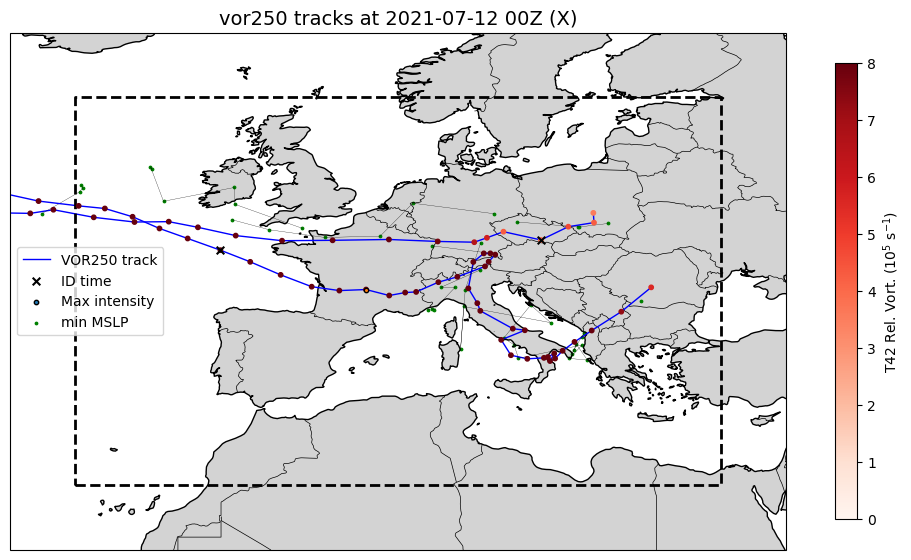



Searching for matching track for Jul2012 at 2012-07-06 00:00:00
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor250_mar-oct2012_DET/ff_trs_pos.addwind250_addwind10m_addmslp_addprecip.new.nc
<xarray.Dataset> Size: 3MB
Dimensions:                    (tracks: 1377, record: 29722)
Coordinates:
    TRACK_ID                   (tracks) int32 6kB ...
    time                       (record) datetime64[ns] 238kB ...
    longitude                  (record) float32 119kB ...
    latitude                   (record) float32 119kB ...
    longitude_1                (record) float32 119kB ...
    latitude_1                 (record) float32 119kB ...
    longitude_2                (record) float32 119kB ...
    latitude_2                 (record) float32 119kB ...
    longitude_3                (record) float32 119kB ...
    latitude_3                 (record) float32 119kB ...
Dimensions without coordinates: tracks, record
Data variables:
    FIRST_PT                   (tracks) in

,Track ID,Start Time,End Time,Min MSLP (hPa),Max WSP10m (m/s),Max Int Lon,Max Int Lat,Max Int Time
0,699,2012-06-30 12:00:00,2012-07-07 18:00:00,995.587219,17.423861,351.1297,49.355862,2012-07-05


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


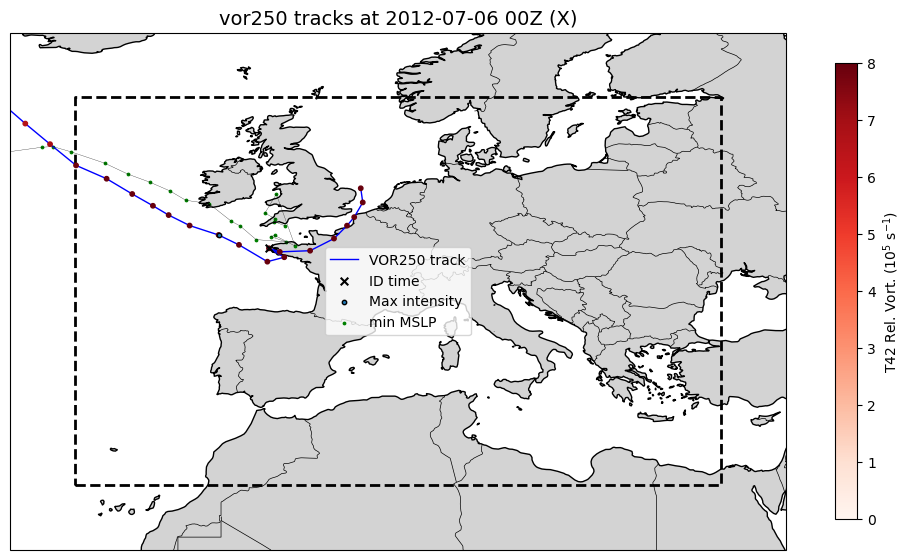

In [2]:
# Locate a specific historical track in the ERA5 CANARI tracks

import numpy as np
import pandas as pd
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from track_utils import wrap_lons, make_era5_track_filename


def locate_tracks(dt, boxlons, boxlats, trackvar='vor850'):
    """
    Print a summary and plot all ERA5 tracks in the box at time dt.

    dt: A datetime.datetime or a range (i.e. [start_time, end_time]).
        If using a range, can only cover one TRACK file.
    boxlons, boxlats: Box to search
    trackvar: Which TRACK files to use ('vor850' or 'mslp')
    """
    if isinstance(dt, datetime.datetime):
        filename = make_era5_track_filename(dt, trackvar=trackvar)
        dt = [dt, dt]
        single_time = True
    else:
        filename = make_era5_track_filename(dt[0], trackvar=trackvar)
        if filename != make_era5_track_filename(dt[1], trackvar=trackvar):
            raise ValueError('If a range given, dt cannot cover more than one TRACK file')
        single_time = False
    print(f'Loading file {filename}')
    ds = xr.open_dataset(filename)

    # Identify qualifying tracks
    selected_tracks = []
    for track_id, first_pt, num_pts in zip(
        ds['TRACK_ID'].values,
        ds['FIRST_PT'].values,
        ds['NUM_PTS'].values
    ):
        sl = slice(first_pt, first_pt + num_pts)
        times = ds['time'].values[sl]
        lats = ds['latitude'].values[sl]
        lons = wrap_lons(ds['longitude'].values[sl])
        is_good = np.any(
            (np.datetime64(dt[0]) <= times) & (times <= np.datetime64(dt[1])) &
            (boxlats[0] <= lats) & (lats <= boxlats[1]) &
            (boxlons[0] <= lons) & (lons <= boxlons[1])
        )
        if is_good:
            selected_tracks.append([track_id, first_pt, num_pts])

    # Print summary of qualifying tracks
    print(f'Found {len(selected_tracks)} qualifying track(s)')
    if len(selected_tracks) == 0:
        return
    summary = []
    for track_id, first_pt, num_pts in selected_tracks:
        sl = slice(first_pt, first_pt + num_pts)
        if 'vor' in trackvar:
            intensity = ds['relative_vorticity'].values[sl]
            maxinti = np.nanargmax(intensity)
        elif trackvar == 'mslp':
            intensity = ds['air_pressure_at_sea_level_anom'].values[sl]
            maxinti = np.nanargmin(intensity)
        summary0 = {
            'Track ID':         int(track_id),
            'Start Time':       ds['time'].values[sl][0],
            'End Time':         ds['time'].values[sl][-1],
            'Min MSLP (hPa)':   float(np.nanmin(ds['air_pressure_at_sea_level'].values[sl])),
            'Max WSP10m (m/s)': float(np.nanmax(ds['wind_speed_10m'].values[sl])),
            'Max Int Lon':      ds['longitude'].values[sl][maxinti],
            'Max Int Lat':      ds['latitude'].values[sl][maxinti],
            'Max Int Time':     ds['time'].values[sl][maxinti],
        }
        summary.append(summary0)
    display(pd.DataFrame(summary))

    # Plot qualifying tracks
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([boxlons[0]-5, boxlons[1]+5, boxlats[0]-5, boxlats[1]+5], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    for track_id, first_pt, num_pts in selected_tracks:
        first_track = (track_id == selected_tracks[0][0])
        sl = slice(first_pt, first_pt + num_pts)

        times = ds['time'].values[sl]
        lats = ds['latitude'].values[sl]
        lons = wrap_lons(ds['longitude'].values[sl])
        lats_mslp = ds['latitude_3'].values[sl]              # Assume latitude_3 for MSLP
        lons_mslp = wrap_lons(ds['longitude_3'].values[sl])  # Assume latitude_3 for MSLP
        if 'vor' in trackvar:
            intensity = ds['relative_vorticity'].values[sl]
            vmin = 0
            vmax = 8
            cmap = 'Reds'
            maxinti = np.nanargmax(intensity)
            cbarlab = "T42 Rel. Vort. (10$^5$ s$^{-1}$)"
        elif trackvar == 'mslp':
            intensity = ds['air_pressure_at_sea_level_anom'].values[sl]
            vmin = 0
            vmax = 10
            cmap = 'Blues'
            maxinti = np.nanargmin(intensity)
            cbarlab = "MSLP anom (hPa)"

        # Line for trajectory
        ax.plot(
            lons, lats, color='blue', linewidth=1,
            transform=ccrs.PlateCarree(),
            label=f'{trackvar.upper()} track' if first_track else None
        )

        # Dots for intensity
        sc = ax.scatter(
            lons, lats, c=intensity, s=10,
            transform=ccrs.PlateCarree(), zorder=3,
            vmin=vmin, vmax=vmax, cmap=cmap
        )

        # Cross at time dt
        if single_time:
            i = np.where(np.datetime64(dt[0]) == times)
            ax.scatter(
                lons[i], lats[i], color='k', s=30, marker='x',
                transform=ccrs.PlateCarree(), zorder=10,
                label='ID time' if first_track else None
            )

        # Dot at max intensity
        ax.scatter(
            lons[maxinti], lats[maxinti], edgecolor='k', s=10, marker='o',
            transform=ccrs.PlateCarree(), zorder=10,
            label='Max intensity' if first_track else None
        )

        # Line for MSLP min
        ax.scatter(
            lons_mslp, lats_mslp, color='green', marker='o', s=3,
            transform=ccrs.PlateCarree(),
            label='min MSLP' if first_track else None
        )
        ax.plot(
            lons_mslp, lats_mslp, color='k', linewidth=0.2,
            transform=ccrs.PlateCarree()
        )

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.8, pad=0.05)
    cbar.set_label(cbarlab)

    # Overlay the target box
    ax.plot(
        [boxlons[i] for i in [0, 1, 1, 0, 0]],
        [boxlats[i] for i in [0, 0, 1, 1, 0]],
        color='black', linewidth=2, linestyle='--', transform=ccrs.PlateCarree())
    ax.legend()

    if single_time:
        plt.title(f'{trackvar} tracks at {dt[0].strftime('%Y-%m-%d %HZ')} (X)', fontsize=14)
    else:
        plt.title(f'{trackvar} tracks in {dt[0].strftime('%Y-%m-%d %HZ')} to {dt[1].strftime('%Y-%m-%d %HZ')}', fontsize=14)
    plt.tight_layout()
    plt.show()
    return summary


# # Farrell's Analogue Cases
# cases = {
#     # 'Arwen':      datetime.datetime(2021, 11, 27),
#     # 'Ophelia':    datetime.datetime(2017, 10, 17),
#     # 'GreatStorm': datetime.datetime(1987, 10, 16),
#     # 'Martin':     datetime.datetime(1999, 12, 28),
#     # 'NorthSea':   datetime.datetime(1953,  2,  1),
#     # 'Eunice':     datetime.datetime(2022,  2, 18),
#     # 'Ciaran':     datetime.datetime(2023, 11,  2),
#     # 'JR':  datetime.datetime(2017, 10, 22),
# }
# boxlons = [-40, 10]
# boxlats = [30, 60]
# trackvar = 'vor850'

# Cut off lows (using vor250)
cases = {
    'Jul2021':    datetime.datetime(2021,  7, 12),
    'Jul2012':    datetime.datetime(2012,  7,  6),
}
boxlons = [-20, 30]
boxlats = [30, 60]
trackvar = 'vor250'

# # Med Cyclones Cases
# # (from Andressa's initialisation time +48 hours - see her fig 1b)
# cases = {
#     'Daniel': datetime.datetime(2023, 9,  11),
#     'Apollo': datetime.datetime(2021, 10, 29, 12),
#     'Ianos':  datetime.datetime(2020, 9,  17),
#     'Detlef': datetime.datetime(2019, 11, 11),
#     'Vaia':   datetime.datetime(2018, 10, 29, 12),
#     'Julia':  datetime.datetime(2012, 2,  6,  12),
#     'Andrea': datetime.datetime(2012, 1,  6)
# }
# boxlons = [0, 30]
# boxlats = [30, 50]
# trackvar = 'vor850'

# Rhidian cases
# cases = {
#     'Groundhog':     datetime.datetime(1976,  2,  2),
# }
# boxlons = [-90, -60]
# boxlats = [30, 50]
# trackvar = 'vor850'
# cases = {
#     'Capella':     datetime.datetime(1976,  1,  3),
#     'DDay':        datetime.datetime(1944, 6, 5),
# }
# boxlons = [-20, 20]
# boxlats = [30, 70]
# trackvar = 'vor850'
# cases = {
#     'Franklin':      datetime.datetime(2023,  9,  1),
# }
# boxlons = [-80, -40]
# boxlats = [30, 50]
# trackvar = 'vor850'


for case, dt in cases.items():
    print(f'\n\nSearching for matching track for {case} at {dt}')
    locate_tracks(dt, boxlons, boxlats, trackvar=trackvar)